In [1]:
import numpy as np

In [7]:
def shell_offsets(max_r):
    shells = {}
    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz
        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        coords = np.column_stack([dx[mask], dy[mask], dz[mask]]).astype(np.int16)
        shells[r] = coords
    return shells

In [19]:
def shell_offsets(max_r):
    shells = []
    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz
        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        coords = np.column_stack([dx[mask], dy[mask], dz[mask]]).astype(np.int16)
        shells.append(coords)   # ← 用 append 比較實際
    return shells  # ← shell 是 object array

In [17]:
def build_shell_cube(max_r):
    """
    回傳一個 3D cube，中心為 (max_r, max_r, max_r)，
    在球殼 r 的位置賦值為 r，其餘為 0。
    """
    size = 2 * max_r + 1
    cube = np.zeros((size, size, size), dtype=np.int16)

    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz

        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        # 把偏移座標轉成 cube 的索引
        x_idx = dx[mask] + max_r
        y_idx = dy[mask] + max_r
        z_idx = dz[mask] + max_r

        cube[x_idx, y_idx, z_idx] = r

    return cube

In [18]:
build_shell_cube(30)

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [20]:
shell_offsets(30)

[array([[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1],
        [ 0,  0,  1],
        [ 0,  1,  0],
        [ 1,  0,  0]], dtype=int16),
 array([[-2,  0,  0],
        [-1, -1, -1],
        [-1, -1,  0],
        [-1, -1,  1],
        [-1,  0, -1],
        [-1,  0,  1],
        [-1,  1, -1],
        [-1,  1,  0],
        [-1,  1,  1],
        [ 0, -2,  0],
        [ 0, -1, -1],
        [ 0, -1,  1],
        [ 0,  0, -2],
        [ 0,  0,  2],
        [ 0,  1, -1],
        [ 0,  1,  1],
        [ 0,  2,  0],
        [ 1, -1, -1],
        [ 1, -1,  0],
        [ 1, -1,  1],
        [ 1,  0, -1],
        [ 1,  0,  1],
        [ 1,  1, -1],
        [ 1,  1,  0],
        [ 1,  1,  1],
        [ 2,  0,  0]], dtype=int16),
 array([[-3,  0,  0],
        [-2, -2, -1],
        [-2, -2,  0],
        [-2, -2,  1],
        [-2, -1, -2],
        [-2, -1, -1],
        [-2, -1,  0],
        [-2, -1,  1],
        [-2, -1,  2],
        [-2,  0, -2],
        [-2,  0, -1],
        [-2,  0,  1],
  

In [21]:
import numpy as np

def build_distance_shell_ball(max_r):
    """
    建立一個「由不同大小球殼組成的距離球」3D cube。

    回傳一個整數 cube，shape = (2*max_r+1, 2*max_r+1, 2*max_r+1)
    - 中心 (max_r, max_r, max_r) 當作球心
    - 對於 dist = sqrt(dx^2 + dy^2 + dz^2) <= max_r：
        value = ceil(dist)   → 第幾層球殼 (1, 2, ..., max_r)
    - 對於 dist > max_r：
        value = -1           → 球外的區域
    """
    size = 2 * max_r + 1
    coords = np.arange(-max_r, max_r + 1)

    dx, dy, dz = np.meshgrid(coords, coords, coords, indexing="ij")
    dist = np.sqrt(dx*dx + dy*dy + dz*dz)

    # 先用 ceil 把距離量化成 0,1,...,max_r
    shells = np.ceil(dist).astype(np.int16)

    # 球外的地方標成 -1
    shells[dist > max_r] = -1

    # 中心點 dist = 0，ceil(0)=0，這裡若希望最裡面也算「第 1 層」，就改成 1
    center = max_r
    shells[center, center, center] = 1

    return shells

In [ ]:
build_distance_shell_ball(3)

(7, 7, 7)

In [9]:
import numpy as np

def build_ball_offsets(max_r):
    """
    建立「距離球殼」的 offsets：
      - offsets: (N, 3)，每列是 (dv, dz, dx)
      - shell_k: (N,)，每個 offset 對應的殼層 index (1..max_r)

    定義：
      dist = sqrt(dv^2 + dz^2 + dx^2)
      1 <= ceil(dist) <= max_r 的點會被保留
    """
    coords = np.arange(-max_r, max_r + 1)
    dv, dz, dx = np.meshgrid(coords, coords, coords, indexing="ij")
    dist = np.sqrt(dv*dv + dz*dz + dx*dx)

    # 只保留 dist <= max_r 的點
    mask = dist <= max_r
    dv_sel = dv[mask]
    dz_sel = dz[mask]
    dx_sel = dx[mask]
    dist_sel = dist[mask]

    # 殼層 index：ceil(dist)，中心點 dist=0 → 設成 1 層
    shell_k = np.ceil(dist_sel).astype(np.int16)
    shell_k[dist_sel == 0.0] = 1

    offsets = np.column_stack([dv_sel, dz_sel, dx_sel]).astype(np.int16)
    return offsets, shell_k

In [10]:
def apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r):
    """
    給定一條 3D 線 (v_line, z_line, x_line)，在 cube 裡為每個 voxel
    標上「距離這條線最近的球殼 index」。

    回傳:
      shell_cube: shape = cube_shape，int16
        - 值 = 1..max_r → 距離線大約為該殼層
        - 值 = -1        → 超出 max_r 以外（沒有被任何球殼覆蓋）
    """
    nv, nz, nx = cube_shape
    shell_cube = np.full(cube_shape, -1, dtype=np.int16)

    # 預先算好球殼 offsets 和對應的殼層 index
    offsets, shell_k = build_ball_offsets(max_r)
    dv_off = offsets[:, 0]
    dz_off = offsets[:, 1]
    dx_off = offsets[:, 2]

    v_line = np.asarray(v_line, dtype=int)
    z_line = np.asarray(z_line, dtype=int)
    x_line = np.asarray(x_line, dtype=int)

    for v0, z0, x0 in zip(v_line, z_line, x_line):
        # 對這個線上的點，把整顆 ball 平移過去
        v_idx = v0 + dv_off
        z_idx = z0 + dz_off
        x_idx = x0 + dx_off

        # 只保留有落在 cube 內的 voxel
        in_bounds = (
            (v_idx >= 0) & (v_idx < nv) &
            (z_idx >= 0) & (z_idx < nz) &
            (x_idx >= 0) & (x_idx < nx)
        )
        if not np.any(in_bounds):
            continue

        v_sel = v_idx[in_bounds]
        z_sel = z_idx[in_bounds]
        x_sel = x_idx[in_bounds]
        k_sel = shell_k[in_bounds]

        # 目前 cube 裡的值
        cur = shell_cube[v_sel, z_sel, x_sel]

        # 更新條件：
        #   - 原本是 -1（還沒被任何球覆蓋）
        #   - 或原本的值 > 新的殼層 index（新球更靠近線）
        update_mask = (cur < 0) | (cur > k_sel)

        shell_cube[v_sel[update_mask],
                   z_sel[update_mask],
                   x_sel[update_mask]] = k_sel[update_mask]

    return shell_cube

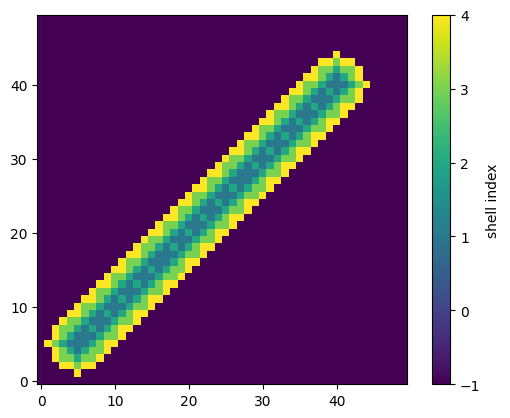

In [12]:
# 假設 cube 是 50×50×50
cube_shape = (50, 50, 50)

# 做一條斜斜的線
t = np.linspace(5, 40, 20).astype(int)
v_line = t
z_line = 25 + 0*t   # 固定在中間
x_line = t          # 對角線

shell_cube = pss.apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r=4)

# 看看某個切片
import matplotlib.pyplot as plt
plt.imshow(shell_cube[:, 25, :], origin="lower")
plt.colorbar(label="shell index")
plt.show()

In [3]:
import PSSpy as pss

In [18]:
offset, shell = pss.build_ball_offsets(3)
print(shell)
print(offset[0:10])

[2 3 3 3 3 3 3]
[[1 1 1]
 [1 1 2]
 [1 2 1]
 [1 2 2]
 [2 1 1]
 [2 1 2]
 [2 2 1]]


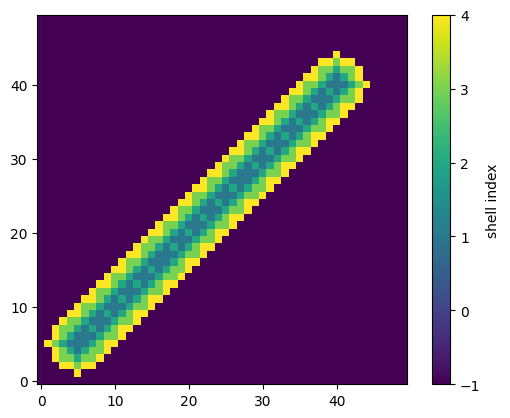

In [23]:
# 假設 cube 是 50×50×50
cube_shape = (50, 50, 50)

# 做一條斜斜的線
t = np.linspace(5, 40, 20).astype(int)
v_line = t
z_line = 25 + 0*t   # 固定在中間
x_line = t          # 對角線

shell_cube = pss.apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r=4)

# 看看某個切片
import matplotlib.pyplot as plt
plt.imshow(shell_cube[:, 25, :], origin="lower")
plt.colorbar(label="shell index")
plt.show()

In [ ]:
import scipy.constants as spc
import PSSpy as pss
import numpy as np
Target = "Per-emb-50"
T_factor_range = (14.744, 678)
radius_ref_au = 240
M_star = 2.58
M_SUN_KG = 1.98847e30

Omega_ref = pss.Omega_ref(radius_ref_au, M_star)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
T_range = [T_factor_range[0]*P_half_Myr, T_factor_range[1]*P_half_Myr]

M_0_max = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[0] * 1e6 * spc.year)
M_0_min = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[1] * 1e6 * spc.year)

print(f"\n==================== Parameters ({Target}) ====================")
print(f"M_0_min          = {M_0_min:.3e}")
print(f"M_0_max          = {M_0_max:.3e}")
print("===============================================================")


==================== Parameters (Per-emb-50) ====================
M_0_min          = 1.000e+00
M_0_max          = 4.600e+01


In [60]:
rms_moment0 = 3.020265757777e-1

3 * rms_moment0

0.9060797273330999

In [193]:
import scipy.constants as spc
import PSSpy as pss
import numpy as np
Target = "SCrA"
T_factor_range = (10.062, 462.7)
radius_ref_au = 240
M_star = 2
M_SUN_KG = 1.98847e30

Omega_ref = pss.Omega_ref(radius_ref_au, M_star)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
T_range = [T_factor_range[0]*P_half_Myr, T_factor_range[1]*P_half_Myr]

M_0_max = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[0] * 1e6 * spc.year)
M_0_min = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[1] * 1e6 * spc.year)

print(f"\n==================== Parameters ({Target}) ====================")
print(f"M_0_min          = {M_0_min:.3e}")
print(f"M_0_max          = {M_0_max:.3e}")
print(T_range)
print("===============================================================")


==================== Parameters (SCrA) ====================
M_0_min          = 1.000e+00
M_0_max          = 4.600e+01
[np.float64(0.013235951835592544), np.float64(0.6086538376395021)]


In [114]:
import scipy.constants as spc
import PSSpy as pss
import numpy as np
Target = "HLTau"
T_factor_range = (3.966, 182.4)
radius_ref_au = 300
M_star = 2.1
M_SUN_KG = 1.98847e30

Omega_ref = pss.Omega_ref(radius_ref_au, M_star)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
T_range = [T_factor_range[0]*P_half_Myr, T_factor_range[1]*P_half_Myr]

M_0_max = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[0] * 1e6 * spc.year)
M_0_min = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[1] * 1e6 * spc.year)

print(f"\n==================== Parameters ({Target}) ====================")
print(f"M_0_min          = {M_0_min:.3e}")
print(f"M_0_max          = {M_0_max:.3e}")
print("===============================================================")


==================== Parameters (HLTau) ====================
M_0_min          = 1.000e+00
M_0_max          = 4.600e+01


In [ ]:
M_star = 2.1
T_best = 0.072
M_dot = M_star / (T_best * 1e6)

np.float64(0.49999999999999994)

In [19]:
import scipy.constants as spc
import PSSpy as pss
import numpy as np
Target = "Per-emb-2"
T_factor_range = (3.62e-2, 5e-1)
c_s = 200
M_star = 3.2
M_SUN_KG = 1.98847e30

M_0_max = M_star * M_SUN_KG * spc.G / (c_s**3 * T_factor_range[0] * 1e6 * spc.year)
M_0_min = M_star * M_SUN_KG * spc.G / (c_s**3 * T_factor_range[1] * 1e6 * spc.year)

print(f"\n==================== Parameters ({Target}) ====================")
print(f"M_0_min          = {M_0_min:.3e}")
print(f"M_0_max          = {M_0_max:.3e}")
print("===============================================================")


==================== Parameters (Per-emb-2) ====================
M_0_min          = 3.367e+00
M_0_max          = 4.650e+01


In [20]:
import scipy.constants as spc

M_SUN_KG = 1.98847e30

def get_T_factor_range(
    M_star,
    Target="Unknown",
    c_s=200,
    M0_min=0.975,
    M0_max=46.7,
):
    """
    根據指定的 M_star，反推出符合
    M_0_min 與 M_0_max 的 T_factor_range。

    Parameters
    ----------
    M_star : float
        Stellar mass in solar mass (Msun)
    Target : str
        Target name (for printing)
    c_s : float
        Sound speed (m/s), default = 200
    M0_min : float
        Minimum M_0 (dimensionless)
    M0_max : float
        Maximum M_0 (dimensionless)

    Returns
    -------
    T_factor_range : tuple
        (T_factor_min, T_factor_max)
    """

    # 單位：kg
    M_star_kg = M_star * M_SUN_KG

    # 對應 M_0_max → T_factor_min
    T_factor_min = (
        M_star_kg * spc.G
        / (c_s**3 * M0_max * 1e6 * spc.year)
    )

    # 對應 M_0_min → T_factor_max
    T_factor_max = (
        M_star_kg * spc.G
        / (c_s**3 * M0_min * 1e6 * spc.year)
    )

    print(f"\n==================== Parameters ({Target}) ====================")
    print(f"M_star           = {M_star:.2f} Msun")
    print(f"M_0_min          = {M0_min:.3f}")
    print(f"M_0_max          = {M0_max:.3f}")
    print(f"T_factor_min     = {T_factor_min:.3e}")
    print(f"T_factor_max     = {T_factor_max:.3e}")
    print("===============================================================")

    return (T_factor_min, T_factor_max)

In [21]:
Target = "Per-emb-2"
M_star = 3.2

T_factor_range = get_T_factor_range(
    M_star=M_star,
    Target=Target
)


==================== Parameters (Per-emb-2) ====================
M_star           = 3.20 Msun
M_0_min          = 0.975
M_0_max          = 46.700
T_factor_min     = 3.605e-02
T_factor_max     = 1.727e+00


In [22]:
Target = "Per-emb-50"
M_star = 2.58

T_factor_range = get_T_factor_range(
    M_star=M_star,
    Target=Target
)


==================== Parameters (Per-emb-50) ====================
M_star           = 2.58 Msun
M_0_min          = 0.975
M_0_max          = 46.700
T_factor_min     = 2.906e-02
T_factor_max     = 1.392e+00


In [23]:
Target = "SCrA"
M_star = 2

T_factor_range = get_T_factor_range(
    M_star=M_star,
    Target=Target
)


==================== Parameters (SCrA) ====================
M_star           = 2.00 Msun
M_0_min          = 0.975
M_0_max          = 46.700
T_factor_min     = 2.253e-02
T_factor_max     = 1.079e+00


In [24]:
Target = "HLTau"
M_star = 2.1

T_factor_range = get_T_factor_range(
    M_star=M_star,
    Target=Target
)


==================== Parameters (HLTau) ====================
M_star           = 2.10 Msun
M_0_min          = 0.975
M_0_max          = 46.700
T_factor_min     = 2.366e-02
T_factor_max     = 1.133e+00


In [3]:
import scipy.constants as spc
spc.astronomical_unit

149597870700.0

# Per-emb-2

In [11]:
import numpy as np
M_SUN_KG = 1.98847e30

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 3.2
    t = 0.28
    sig_minus = 0.13
    sig_plus = 0.14

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.15000000000000002 0.42000000000000004
Mdot (Msun/yr): 1.1428571428571429e-05
Mdot_lower (Msun/yr): 7.619047619047619e-06
Mdot_upper (Msun/yr): 2.133333333333333e-05
(-, +) errors: 3.8095238095238102e-06 9.904761904761902e-06
r_s (au): 11813.173487903126
r_low (au): 6328.4857970909625
r_high (au): 17719.760231854692
(-, +) errors: 5484.687690812164 5906.586743951566
m_0: 6.007900890978492
m_0_err_minus: 2.002633630326165
m_0_err_plus: 5.206847438848023


In [12]:
import numpy as np

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 3.2
    t = 0.27
    sig_minus = 0.12
    sig_plus = 0.15

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.15000000000000002 0.42000000000000004
Mdot (Msun/yr): 1.1851851851851853e-05
Mdot_lower (Msun/yr): 7.619047619047619e-06
Mdot_upper (Msun/yr): 2.133333333333333e-05
(-, +) errors: 4.2328042328042345e-06 9.481481481481478e-06
r_s (au): 11391.274434763729
r_low (au): 6328.4857970909625
r_high (au): 17719.760231854692
(-, +) errors: 5062.7886376727665 6328.485797090963
m_0: 6.23041573879251
m_0_err_minus: 2.2251484781401825
m_0_err_plus: 4.984332591034005


# Per-emb-50

In [13]:
import numpy as np

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2.58
    t = 0.73
    sig_minus = 0.49
    sig_plus = 0.67

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.24 1.4
Mdot (Msun/yr): 3.534246575342466e-06
Mdot_lower (Msun/yr): 1.8428571428571428e-06
Mdot_upper (Msun/yr): 1.075e-05
(-, +) errors: 1.6913894324853232e-06 7.215753424657535e-06
r_s (au): 30798.63087917601
r_low (au): 10125.577275345537
r_high (au): 59065.867439515634
(-, +) errors: 20673.05360383047 28267.236560339625
m_0: 1.8579227755320473
m_0_err_minus: 0.8829227755320473
m_0_err_plus: 3.7932590000445967


In [14]:
import numpy as np

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2.58
    t = 0.83
    sig_minus = 0.56
    sig_plus = 0.61

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.2699999999999999 1.44
Mdot (Msun/yr): 3.1084337349397593e-06
Mdot_lower (Msun/yr): 1.7916666666666667e-06
Mdot_upper (Msun/yr): 9.55555555555556e-06
(-, +) errors: 1.3167670682730925e-06 6.447121820615801e-06
r_s (au): 35017.621410569984
r_low (au): 11391.274434763725
r_high (au): 60753.463652073224
(-, +) errors: 23626.346975806257 25735.84224150324
m_0: 1.634076657998066
m_0_err_minus: 0.6590766579980659
m_0_err_plus: 3.389196031403398


# S CrA

In [15]:
import numpy as np

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2
    t = 0.79
    sig_minus = 0.46
    sig_plus = 0.41

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.33 1.2
Mdot (Msun/yr): 2.531645569620253e-06
Mdot_lower (Msun/yr): 1.6666666666666667e-06
Mdot_upper (Msun/yr): 6.060606060606061e-06
(-, +) errors: 8.649789029535864e-07 3.528960490985808e-06
r_s (au): 33330.025198012394
r_low (au): 13922.668753600114
r_high (au): 50627.886376727685
(-, +) errors: 19407.356444412282 17297.86117871529
m_0: 1.330864121419286
m_0_err_minus: 0.35586412141928603
m_0_err_plus: 1.8551439268268834


In [16]:
import numpy as np

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit
    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2
    t = 0.94
    sig_minus = 0.37
    sig_plus = 0.32

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.57 1.26
Mdot (Msun/yr): 2.1276595744680853e-06
Mdot_lower (Msun/yr): 1.5873015873015873e-06
Mdot_upper (Msun/yr): 3.5087719298245615e-06
(-, +) errors: 5.40357987166498e-07 1.3811123553564762e-06
r_s (au): 39658.51099510335
r_low (au): 24048.24602894565
r_high (au): 53159.28069556407
(-, +) errors: 15610.264966157702 13500.769700460718
m_0: 1.1184921871502511
m_0_err_minus: 0.14349218715025114
m_0_err_plus: 0.7260387881501629


# HL Tau

In [21]:
import numpy as np
import scipy.constants as spc

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit

    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2.1
    t = 0.74
    sig_minus = 0.47
    sig_plus = 0.47

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    # print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    # print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])

t_low, t_high (Myr): 0.27 1.21
Mdot (Msun/yr): 2.837837837837838e-06
(-, +) errors: 1.1023006477551933e-06 4.939939939939939e-06
r_s (au): 31220.529932315407
r_low (au): 11391.274434763729
r_high (au): 51049.785429867086
(-, +) errors: 19829.255497551676 19829.25549755168
m_0: 1.491826741509862
m_0_err_minus: 0.5168267415098621
m_0_err_plus: 2.596883587072723


In [23]:
import numpy as np
import scipy.constants as spc

def mdot_bounds_from_ts(M_star_msun, t_myr, sigma_minus_myr, sigma_plus_myr):
    """
    Compute Mdot = M_star / t_s and its asymmetric bounds from t_s uncertainties.

    Parameters
    ----------
    M_star_msun : float
        Stellar mass in Msun.
    t_myr : float
        Collapse timescale t_s in Myr.
    sigma_minus_myr : float
        Lower uncertainty on t_s (i.e., t_s - sigma_minus).
    sigma_plus_myr : float
        Upper uncertainty on t_s (i.e., t_s + sigma_plus).

    Returns
    -------
    out : dict
        {
          "mdot": central Mdot [Msun/yr],
          "mdot_upper": upper bound [Msun/yr]  (using t_s - sigma_minus),
          "mdot_lower": lower bound [Msun/yr]  (using t_s + sigma_plus),
          "err_plus": + error relative to central [Msun/yr],
          "err_minus": - error relative to central [Msun/yr],
          "t_low": t_s - sigma_minus [Myr],
          "t_high": t_s + sigma_plus [Myr],
        }
    """
    if t_myr <= 0:
        raise ValueError("t_myr must be > 0.")
    if sigma_minus_myr < 0 or sigma_plus_myr < 0:
        raise ValueError("Uncertainties must be >= 0.")
    t_low = t_myr - sigma_minus_myr
    t_high = t_myr + sigma_plus_myr
    if t_low <= 0:
        raise ValueError("t_myr - sigma_minus_myr must be > 0 (otherwise Mdot diverges).")

    # Myr -> yr
    t_yr = t_myr * 1e6
    t_low_yr = t_low * 1e6
    t_high_yr = t_high * 1e6
    t_sec = t_myr * 1e6 * 3600 * 24 * 365.25
    t_low_sec = t_low * 1e6 * 3600 * 24 * 365.25
    t_high_sec = t_high * 1e6 * 3600 * 24 * 365.25
    c_s = 200  # m/s
    r_s = (c_s * t_sec) / spc.astronomical_unit
    r_low = (c_s * t_low_sec) / spc.astronomical_unit
    r_high = (c_s * t_high_sec) / spc.astronomical_unit

    mdot = M_star_msun / t_yr
    mdot_upper = M_star_msun / t_low_yr   # smaller t -> larger mdot
    mdot_lower = M_star_msun / t_high_yr  # larger t -> smaller mdot
    m_0 = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_sec)
    m_0_low = max((spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_high_sec), 0.975)
    m_0_high = (spc.G * M_star_msun * M_SUN_KG) / (c_s**3 * t_low_sec)

    return {
        "mdot": mdot,
        "mdot_upper": mdot_upper,
        "mdot_lower": mdot_lower,
        "err_plus": mdot_upper - mdot,
        "err_minus": mdot - mdot_lower,
        "t_low": t_low,
        "t_high": t_high,
        "r_s": r_s,
        "r_error_minus": r_s - r_low,
        "r_error_plus": r_high - r_s,
        "r_low": r_low,
        "r_high": r_high,
        "m_0": m_0,
        "m_0_low": m_0_low,
        "m_0_high": m_0_high,
        "m_0_err_minus": m_0 - m_0_low,
        "m_0_err_plus": m_0_high - m_0,
    }


# ---- Example (your Per-emb-2 numbers) ----
if __name__ == "__main__":
    M_star = 2.1
    t = 0.79
    sig_minus = 0.45
    sig_plus = 0.46

    res = mdot_bounds_from_ts(M_star, t, sig_minus, sig_plus)
    print("t_low, t_high (Myr):", res["t_low"], res["t_high"])
    print("Mdot (Msun/yr):", res["mdot"])
    # print("Mdot_lower (Msun/yr):", res["mdot_lower"])
    # print("Mdot_upper (Msun/yr):", res["mdot_upper"])
    print("(-, +) errors:", res["err_minus"], res["err_plus"])
    print("r_s (au):", res["r_s"])
    print("r_low (au):", res["r_low"])
    print("r_high (au):", res["r_high"])
    print("(-, +) errors:", res["r_error_minus"], res["r_error_plus"])
    print("m_0:", res["m_0"])
    print("m_0_low:", res["m_0_low"])
    print("m_0_err_minus:", res["m_0_err_minus"])
    print("m_0_err_plus:", res["m_0_err_plus"])
    


t_low, t_high (Myr): 0.34 1.25
Mdot (Msun/yr): 2.6582278481012658e-06
(-, +) errors: 9.782278481012658e-07 3.5182427401340286e-06
r_s (au): 33330.025198012394
r_low (au): 14344.567806739511
r_high (au): 52737.381642424676
(-, +) errors: 18985.45739127288 19407.356444412282
m_0: 1.3974073274902505
m_0_low: 0.975
m_0_err_minus: 0.42240732749025056
m_0_err_plus: 1.849509698148861
